In [111]:
import os
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import seaborn as sns
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR
from torch.optim.lr_scheduler import SequentialLR

In [112]:
path = kagglehub.dataset_download("anshtanwar/pets-facial-expression-dataset")
path = os.path.join(path, 'Master Folder')

In [113]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [114]:
train_ds = datasets.ImageFolder(os.path.join(path, 'train'), data_transforms['train'])
val_ds   = datasets.ImageFolder(os.path.join(path, 'valid'), data_transforms['val'])
test_ds  = datasets.ImageFolder(os.path.join(path, 'test'),  data_transforms['val'])

dataset_sizes = {
    'train': len(train_ds),
    'val':   len(val_ds),
    'test':  len(test_ds)
}

In [115]:
dataloaders = {
    'train': DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2),
    'val':   DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2),
    'test':  DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)
}

class_names = train_ds.classes
class_names

['Angry', 'Other', 'Sad', 'happy']

In [116]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


In [117]:
# Load DenseNet121 with ImageNet weights
torch.manual_seed(42)
torch.cuda.manual_seed(42)
base_model = models.densenet121(weights='IMAGENET1K_V1')
# Replace the final fully connected layer
num_classes = len(class_names) 
in_features = base_model.classifier.in_features
base_model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),   
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)


In [118]:
for param in base_model.parameters():
    param.requires_grad = False
for param in base_model.classifier.parameters():
        param.requires_grad = True

In [119]:
model = base_model.to(device)
optimizer = optim.Adam(model.classifier.parameters(),lr=1e-4, weight_decay=5e-3 )

label_counts = Counter(train_ds.targets)
total_samples = sum(label_counts.values())
class_weights = torch.tensor(
    [total_samples / label_counts[i] for i in range(num_classes)],
    dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)    


EPOCHS = 20
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [120]:
# Training loop
best_val_acc = 0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in dataloaders["train"]:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
        
    train_losses.append(running_loss / len(dataloaders["train"]))
    train_accs.append(100. * correct / total)

    # ── Validate ──
    model.eval()
    val_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloaders["val"]:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

    val_losses.append(val_loss / len(dataloaders["val"]))
    val_accs.append(100. * correct / total)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    # ── Save best model ──
    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.2f}% | "
          f"Val Loss: {val_losses[-1]:.4f} Acc: {val_accs[-1]:.2f}%"
           f"{'  ← best' if val_accs[-1] == best_val_acc else ''}"
          f" LR: {current_lr:.2e} "
         )

Epoch [01/20] Train Loss: 1.3782 Acc: 29.40% | Val Loss: 1.2351 Acc: 36.11%  ← best LR: 1.00e-04 
Epoch [02/20] Train Loss: 1.2897 Acc: 43.20% | Val Loss: 1.1992 Acc: 44.44%  ← best LR: 9.94e-05 
Epoch [03/20] Train Loss: 1.2430 Acc: 44.60% | Val Loss: 1.2127 Acc: 41.67% LR: 9.76e-05 
Epoch [04/20] Train Loss: 1.2154 Acc: 46.80% | Val Loss: 1.1888 Acc: 44.44%  ← best LR: 9.46e-05 
Epoch [05/20] Train Loss: 1.1979 Acc: 49.10% | Val Loss: 1.0609 Acc: 47.22%  ← best LR: 9.05e-05 
Epoch [06/20] Train Loss: 1.1730 Acc: 48.50% | Val Loss: 1.1296 Acc: 50.00%  ← best LR: 8.55e-05 
Epoch [07/20] Train Loss: 1.1504 Acc: 50.90% | Val Loss: 1.1381 Acc: 41.67% LR: 7.96e-05 
Epoch [08/20] Train Loss: 1.1168 Acc: 53.80% | Val Loss: 1.1360 Acc: 44.44% LR: 7.30e-05 
Epoch [09/20] Train Loss: 1.1081 Acc: 51.40% | Val Loss: 1.1180 Acc: 52.78%  ← best LR: 6.58e-05 
Epoch [10/20] Train Loss: 1.1051 Acc: 53.90% | Val Loss: 1.1141 Acc: 50.00% LR: 5.82e-05 
Epoch [11/20] Train Loss: 1.0958 Acc: 55.00% | Val L

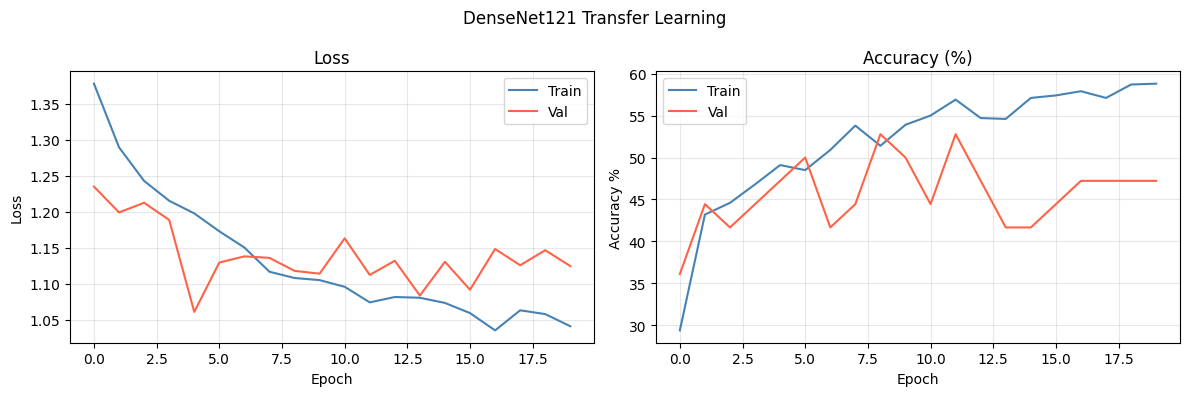

In [121]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train', color='steelblue')
ax1.plot(val_losses,   label='Val',   color='tomato')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train', color='steelblue')
ax2.plot(val_accs,   label='Val',   color='tomato')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy %')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('DenseNet121 Transfer Learning')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

In [122]:
# Load best saved model before evaluating
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
model.eval()
all_preds, all_labels = [], [] 
with torch.no_grad():
    for images, labels in dataloaders["test"]:
        images = images.to(device)
        outputs = model(images)

        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))   
cm = confusion_matrix(all_labels, all_preds)
print(cm)
#53% accuracy on test set

              precision    recall  f1-score   support

       Angry       0.50      0.80      0.62        10
       Other       0.00      0.00      0.00         6
         Sad       0.62      0.45      0.53        11
       happy       0.54      0.64      0.58        11

    accuracy                           0.53        38
   macro avg       0.42      0.47      0.43        38
weighted avg       0.47      0.53      0.48        38

[[8 1 0 1]
 [4 0 1 1]
 [2 0 5 4]
 [2 0 2 7]]


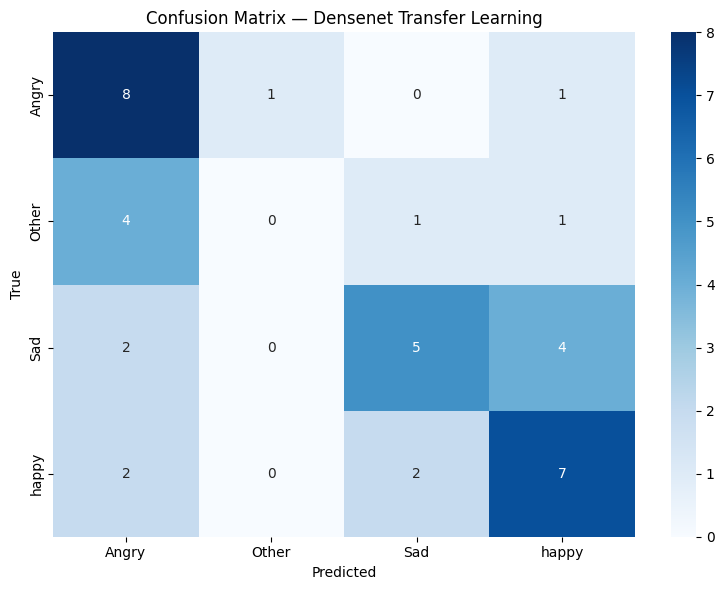

In [123]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Densenet Transfer Learning')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()